# Klasifikasi Penyakit Daun Tomat dengan CNN
MBC Lab (Week 2)

---

Nama: Nada Thahira Sosa

Kode CaAs: 2601

---

### Soal 2 — Tomato Leaf Disease Dataset (10 Kelas)

Notebook ini mengikuti alur yang sama seperti Soal 1, tapi diterapkan pada dataset yang jauh lebih kompleks: **10 kelas** penyakit daun tomat (dibanding 2 kelas pada Apple vs Orange).

## Alur Pengerjaan

Notebook ini berisi proses pengembangan dan evaluasi model **klasifikasi penyakit daun tomat** menggunakan pendekatan **CNN Custom** dan **Transfer Learning dengan MobileNetV2**. Proses pengerjaan dilakukan secara bertahap, mulai dari memahami dataset hingga menentukan model terbaik berdasarkan hasil evaluasi.

### Alur utama notebook:

**1. Data Loading & Exploratory Data Analysis (EDA)**
Memuat dataset gambar daun tomat, memahami struktur dataset, distribusi kelas, serta mengidentifikasi karakteristik dan potensi permasalahan pada data.

**2. Data Preprocessing**
Melakukan persiapan data sebelum masuk ke model, meliputi resize citra, normalisasi, pembagian data, serta augmentasi untuk membantu meningkatkan kemampuan generalisasi model.

**3. Pembangunan CNN Custom**
Membangun arsitektur CNN dari awal yang disesuaikan dengan karakteristik permasalahan klasifikasi 10 kelas penyakit daun tomat. Arsitektur terdiri dari beberapa convolutional block, Batch Normalization, Max Pooling, Global Average Pooling, dan Dense layer.

**4. Training CNN Custom**
Melatih CNN Custom menggunakan data training dengan bantuan callback seperti `EarlyStopping`, `ModelCheckpoint`, dan `ReduceLROnPlateau` untuk mengontrol proses training dan mengurangi risiko overfitting.

**5. Evaluasi CNN Custom**
Mengevaluasi performa model menggunakan **Accuracy** dan **F1 Score**, kemudian menganalisis hasil klasifikasi melalui classification report dan confusion matrix.

**6. Transfer Learning dengan MobileNetV2**
Membangun model pembanding menggunakan MobileNetV2 pretrained ImageNet. Base model dibekukan (*freeze*) dan ditambahkan classifier head baru untuk melakukan klasifikasi 10 kelas penyakit daun tomat.

**7. Training & Evaluasi MobileNetV2**
Melatih classifier pada model transfer learning, kemudian mengevaluasinya menggunakan metrik yang sama dengan CNN Custom agar hasil kedua model dapat dibandingkan secara adil.

**8. Perbandingan Model**
Membandingkan performa **CNN Custom** dan **MobileNetV2 Transfer Learning** berdasarkan Accuracy dan F1 Score (macro), serta menganalisis kelebihan dan kekurangan masing-masing pendekatan.

**9. Pemilihan Model Terbaik**
Menentukan model terbaik berdasarkan **F1 Score (macro)** sebagai metrik utama, karena metrik ini mempertimbangkan performa pada seluruh kelas secara lebih seimbang.

**10. Penyimpanan Model**
Menyimpan model terbaik agar dapat digunakan kembali untuk tahap implementasi atau pengembangan lebih lanjut.

## 1. Setup & Import

In [5]:
import os
import random
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Konfigurasi

Pada tahap awal, dilakukan konfigurasi untuk menyesuaikan proses eksperimen dengan lingkungan komputasi yang tersedia. Salah satu konfigurasi yang digunakan adalah parameter `QUICK_DEMO`.

Nilai `QUICK_DEMO=True` digunakan pada tahap verifikasi awal untuk memastikan seluruh tahapan dalam notebook, mulai dari preprocessing hingga proses training dan evaluasi, dapat berjalan dengan baik. Pada konfigurasi ini, proses dijalankan dengan skala yang lebih ringan sehingga dapat digunakan untuk memeriksa fungsionalitas pipeline tanpa membutuhkan waktu komputasi yang besar.

Setelah pipeline berhasil diverifikasi, eksperimen utama dilakukan dengan mengatur `QUICK_DEMO=False`. Pada konfigurasi tersebut, proses training dijalankan menggunakan data dan parameter eksperimen yang telah ditentukan untuk memperoleh hasil yang digunakan dalam analisis dan evaluasi model.

Dengan demikian, konfigurasi `QUICK_DEMO` digunakan untuk membedakan tahap **verifikasi pipeline** dan **eksperimen utama**. Hasil dari mode demo tidak digunakan sebagai hasil akhir karena konfigurasi tersebut hanya ditujukan untuk memastikan proses pengerjaan dapat berjalan dengan baik.


In [6]:
from pathlib import Path

KAGGLE_PATH_1 = "/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato"
KAGGLE_PATH_2 = "/kaggle/input/tomatoleaf/tomato"
LOCAL_PATH = r"c:\Codingzzzzz\ml\lasmbc\week2\tomatoleaf\tomato"
RELATIVE_PATH = "tomatoleaf/tomato"

def resolve_dataset_path():
    for p in [KAGGLE_PATH_1, KAGGLE_PATH_2, LOCAL_PATH, RELATIVE_PATH]:
        if Path(p).exists():
            print(f"Dataset ditemukan di: {p}")
            return Path(p)
    raise FileNotFoundError("Dataset tidak ditemukan di path manapun. Cek kembali lokasi dataset.")

DATA_DIR = resolve_dataset_path()     
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

QUICK_DEMO = False   

if QUICK_DEMO:
    IMG_SIZE = (96, 96)       
    BATCH_SIZE = 32
    EPOCHS_CUSTOM = 4
    EPOCHS_TRANSFER = 3
    SAMPLES_PER_CLASS_TRAIN = 60    
    SAMPLES_PER_CLASS_VAL = 15
else:
    IMG_SIZE = (224, 224)     
    BATCH_SIZE = 32
    EPOCHS_CUSTOM = 40
    EPOCHS_TRANSFER = 20
    SAMPLES_PER_CLASS_TRAIN = None  
    SAMPLES_PER_CLASS_VAL = None

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)
print(f"Jumlah kelas: {NUM_CLASSES}")
print(CLASSES)

Dataset ditemukan di: /kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato
Jumlah kelas: 10
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset secara lebih menyeluruh sebelum memasuki tahap preprocessing dan pemodelan. Analisis ini tidak hanya berfokus pada distribusi data, tetapi juga digunakan untuk mengidentifikasi kondisi dataset yang dapat memengaruhi strategi preprocessing, pemilihan arsitektur model, serta interpretasi hasil evaluasi.

Beberapa aspek yang menjadi fokus pada tahap EDA meliputi:

1. **Distribusi kelas**
   Menganalisis jumlah data pada setiap kelas untuk mengetahui apakah dataset memiliki distribusi yang seimbang atau terdapat ketimpangan antar kelas. Hasil analisis ini menjadi pertimbangan dalam menentukan apakah diperlukan penanganan khusus, seperti *class weighting*.

2. **Ukuran dan format citra**
   Memeriksa dimensi, format, dan karakteristik dasar citra untuk memastikan konsistensi data. Informasi ini digunakan sebagai dasar dalam menentukan strategi *image resizing* dan input yang sesuai untuk model.

3. **Variasi visual antar kelas**
   Mengamati sampel citra dari setiap kelas untuk memahami karakteristik visual dan tingkat kemiripan antar kelas. Analisis ini membantu memberikan gambaran mengenai kompleksitas permasalahan klasifikasi yang akan ditangani oleh model.

4. **Kondisi dan potensi anomali pada dataset**
   Memeriksa kemungkinan adanya kondisi data yang dapat memengaruhi validitas proses training dan evaluasi, seperti duplikasi citra atau pola augmentasi yang telah dilakukan sebelumnya. Pemeriksaan ini penting untuk memastikan bahwa hasil evaluasi model merepresentasikan kemampuan generalisasi model secara lebih valid.

Dengan demikian, hasil EDA akan digunakan sebagai dasar dalam menentukan pendekatan preprocessing dan pemodelan yang diterapkan pada tahap selanjutnya.


### 3.1 Distribusi Kelas

Analisis distribusi kelas dilakukan sebagai tahap awal untuk mengetahui keseimbangan jumlah sampel pada setiap kelas. Kondisi distribusi kelas perlu diperhatikan karena ketidakseimbangan data dapat menyebabkan model lebih cenderung memprediksi kelas dengan jumlah sampel yang lebih besar.

In [7]:
def count_per_class(split_dir):
    counts = {}
    for cls in CLASSES:
        counts[cls] = len(list((split_dir / cls).glob("*")))
    return counts

train_counts = count_per_class(TRAIN_DIR)
val_counts = count_per_class(VAL_DIR)

df_counts = pd.DataFrame({"train": train_counts, "val": val_counts})
df_counts["total"] = df_counts["train"] + df_counts["val"]
print(df_counts)
print(f"\nTotal gambar train: {df_counts['train'].sum()}, val: {df_counts['val'].sum()}")
print(f"Rasio kelas terbesar/terkecil (train): {df_counts['train'].max()/df_counts['train'].min():.2f}")

                                               train  val  total
Tomato___Bacterial_spot                         1000  100   1100
Tomato___Early_blight                           1000  100   1100
Tomato___Late_blight                            1000  100   1100
Tomato___Leaf_Mold                              1000  100   1100
Tomato___Septoria_leaf_spot                     1000  100   1100
Tomato___Spider_mites Two-spotted_spider_mite   1000  100   1100
Tomato___Target_Spot                            1000  100   1100
Tomato___Tomato_Yellow_Leaf_Curl_Virus          1000  100   1100
Tomato___Tomato_mosaic_virus                    1000  100   1100
Tomato___healthy                                1000  100   1100

Total gambar train: 10000, val: 1000
Rasio kelas terbesar/terkecil (train): 1.00


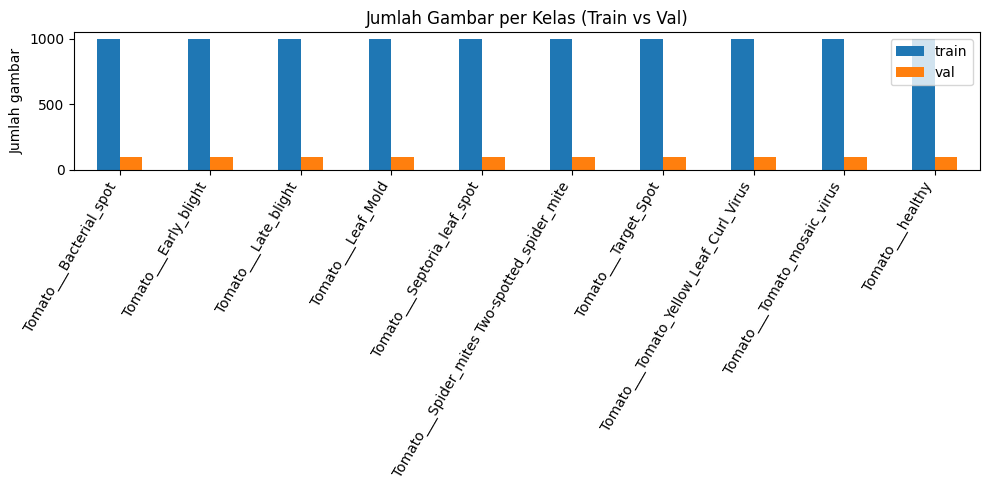

In [8]:
fig, ax = plt.subplots(figsize=(10,5))
df_counts[["train","val"]].plot(kind="bar", ax=ax)
ax.set_title("Jumlah Gambar per Kelas (Train vs Val)")
ax.set_ylabel("Jumlah gambar")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### Analisis

Analisis distribusi kelas dilakukan untuk mengetahui jumlah sampel pada setiap kelas serta memastikan bahwa data yang digunakan memiliki proporsi yang memadai untuk proses training dan validasi.

Berdasarkan hasil tersebut, dataset terdiri atas **10 kelas** dengan masing-masing kelas memiliki **1.000 citra pada data training** dan **100 citra pada data validasi**. Dengan demikian, diperoleh total **10.000 citra training** dan **1.000 citra validasi**.

| Komponen                      | Jumlah |
| ----------------------------- | -----: |
| Jumlah kelas                  |     10 |
| Data training per kelas       |  1.000 |
| Data validasi per kelas       |    100 |
| Total data training           | 10.000 |
| Total data validasi           |  1.000 |
| Rasio kelas terbesar/terkecil |   1,00 |

Distribusi tersebut menunjukkan bahwa seluruh kelas memiliki jumlah sampel yang sama, baik pada data training maupun validasi. Rasio kelas terbesar terhadap kelas terkecil sebesar **1,00** juga mengonfirmasi bahwa tidak terdapat *class imbalance* pada dataset yang digunakan.

Kondisi ini menguntungkan dalam proses pemodelan karena setiap kelas memperoleh jumlah sampel yang sama untuk dipelajari oleh model. Dengan demikian, tidak terdapat kelas tertentu yang secara frekuensi lebih dominan dan berpotensi menyebabkan model lebih cenderung menghasilkan prediksi pada kelas tersebut.

Berdasarkan kondisi tersebut, teknik penanganan ketidakseimbangan kelas seperti **class weighting** atau **oversampling** tidak diperlukan pada tahap ini. Proses preprocessing dapat dilanjutkan tanpa memberikan bobot tambahan terhadap kelas tertentu.

Meskipun distribusi kelas seimbang, evaluasi model tetap dilakukan menggunakan lebih dari satu metrik. **Accuracy** digunakan untuk mengukur proporsi prediksi yang benar secara keseluruhan, sedangkan **F1 Score** digunakan untuk memberikan gambaran performa klasifikasi dengan mempertimbangkan keseimbangan antara precision dan recall pada setiap kelas.

Dengan distribusi yang seimbang pada data training dan validasi, hasil evaluasi yang diperoleh nantinya dapat dianalisis tanpa adanya pengaruh ketimpangan jumlah sampel antar kelas sebagai faktor utama.


### 3.2 Properti Gambar (Ukuran dan Mode Warna)

Pemeriksaan properti gambar dilakukan untuk mengetahui karakteristik dasar citra yang digunakan dalam dataset, khususnya terkait **ukuran (dimensi)** dan **mode warna**. Informasi ini diperlukan untuk menentukan tahapan preprocessing yang sesuai sebelum citra digunakan sebagai input model.

Ukuran gambar perlu diperiksa untuk mengetahui apakah seluruh citra memiliki dimensi yang seragam. Apabila terdapat perbedaan ukuran, maka diperlukan proses **resize** agar seluruh citra memiliki dimensi input yang sama sesuai dengan kebutuhan arsitektur model. Hal ini penting karena model CNN menerima input dengan ukuran yang konsisten.

Selain ukuran, mode warna setiap citra juga diperiksa untuk memastikan format representasi warna yang digunakan. Apabila terdapat citra dengan mode warna yang berbeda, diperlukan proses konversi ke format yang seragam, seperti **RGB**, sehingga seluruh citra memiliki representasi channel warna yang konsisten selama proses training dan evaluasi.

Dengan demikian, pemeriksaan properti gambar menjadi dasar dalam menentukan apakah proses **resize** dan **konversi mode warna** diperlukan pada tahap preprocessing.


In [9]:
sample_files = []
for cls in CLASSES:
    files = list((TRAIN_DIR / cls).glob("*"))
    sample_files.extend(random.sample(files, min(20, len(files))))

sizes = Counter()
modes = Counter()
file_bytes = []
for p in sample_files:
    with Image.open(p) as im:
        sizes[im.size] += 1
        modes[im.mode] += 1
    file_bytes.append(p.stat().st_size)

print("Distribusi ukuran gambar (sample):", sizes.most_common(5))
print("Distribusi mode warna:", modes)
print(f"Ukuran file: min={min(file_bytes)/1024:.1f}KB, max={max(file_bytes)/1024:.1f}KB, avg={np.mean(file_bytes)/1024:.1f}KB")

Distribusi ukuran gambar (sample): [((256, 256), 200)]
Distribusi mode warna: Counter({'RGB': 200})
Ukuran file: min=5.3KB, max=27.4KB, avg=16.4KB


### Analisis

Berdasarkan pemeriksaan terhadap **200 sampel citra**, seluruh gambar memiliki ukuran **256 × 256 piksel** dan mode warna **RGB**. Hal ini menunjukkan bahwa pada sampel yang diperiksa tidak ditemukan variasi dimensi maupun mode warna yang memerlukan penanganan khusus.

Seluruh citra juga memiliki mode warna **RGB**, sehingga setiap gambar telah memiliki tiga channel warna yang konsisten. Oleh karena itu, tidak diperlukan konversi mode warna tambahan sebelum citra digunakan sebagai input model.

Dari sisi ukuran file, citra memiliki ukuran antara **5,3 KB hingga 27,4 KB**, dengan rata-rata sebesar **16,4 KB**. Variasi ukuran file tersebut masih dapat terjadi meskipun dimensi dan mode warna gambar sama, karena ukuran file dipengaruhi oleh karakteristik visual dan tingkat kompresi citra. Variasi ukuran file ini tidak secara langsung menunjukkan adanya masalah pada dataset sehingga tidak diperlukan tindakan preprocessing khusus berdasarkan ukuran file.

### 3.3 Visualisasi Sampel per Kelas

Visualisasi beberapa sampel dari setiap kelas dilakukan untuk memperoleh gambaran mengenai karakteristik visual dataset. Melalui visualisasi ini, dapat terlihat karakteristik seperti **bentuk, warna, pola, serta gejala pada permukaan daun** yang muncul pada masing-masing kelas. Selain itu juga untuk mengidentifikasi tingkat kemiripan visual antar kelas yang dapat menjadi tantangan dalam proses klasifikasi.

Hasil pengamatan terhadap sampel citra selanjutnya digunakan sebagai informasi pendukung dalam menentukan pendekatan pemodelan. Apabila terdapat karakteristik visual yang relatif kompleks atau kemiripan gejala antar kelas, model perlu memiliki kemampuan ekstraksi fitur yang memadai untuk mempelajari pola tersebut secara efektif.

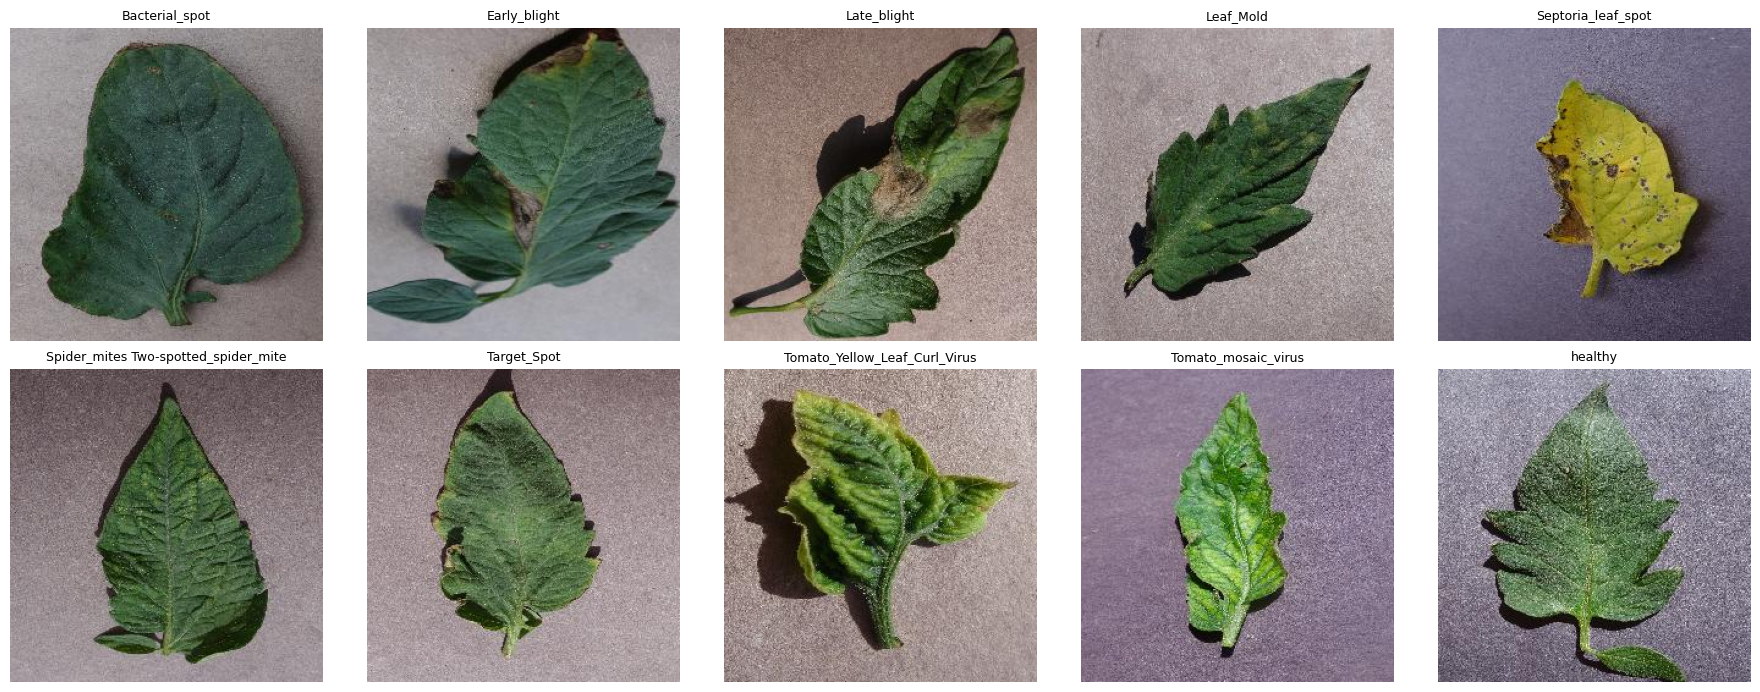

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18,7))
for i, cls in enumerate(CLASSES):
    files = list((TRAIN_DIR / cls).glob("*"))
    img = Image.open(random.choice(files)).convert("RGB")
    ax = axes[i//5, i%5]
    ax.imshow(img)
    ax.set_title(cls.replace("Tomato___",""), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Analisis

Berdasarkan visualisasi sampel, terlihat bahwa beberapa kelas memiliki karakteristik visual yang berpotensi sulit dibedakan, seperti **Early_blight** dan **late_blight** yang sama-sama memperlihatkan perubahan berupa bercak pada permukaan daun, meskipun pola dan tingkat kemunculannya berbeda. Sementara itu, pada **Bacterial Spot**, gejala pada sampel yang ditampilkan terlihat kurang tegas, sehingga perbedaannya tidak selalu dapat dikenali secara langsung melalui pengamatan visual.

Temuan tersebut menunjukkan bahwa proses klasifikasi tidak hanya bergantung pada bentuk keseluruhan daun, tetapi juga pada fitur yang lebih detail seperti **pola bercak, tekstur, perubahan warna, dan distribusi gejala**. Hal ini menjadi salah satu tantangan dalam klasifikasi multikelas karena beberapa kelas dapat memiliki karakteristik visual yang beririsan.



### 3.4 Pemeriksaan Potensi Data Leakage

Pada tahap ini dilakukan pemeriksaan untuk mengetahui apakah terdapat **kemiripan atau keterkaitan antar citra pada data training dan validation** yang berpotensi menyebabkan data leakage.

Pemeriksaan dilakukan dengan menelusuri pola penamaan file pada kedua subset data. Hal ini bertujuan untuk mengidentifikasi kemungkinan adanya citra yang berasal dari sumber yang sama atau merupakan hasil transformasi dari citra lain.

Hasil pemeriksaan selanjutnya digunakan untuk menentukan apakah terdapat potensi data leakage antara data training dan validation yang perlu diperhatikan sebelum proses pemodelan dilakukan.


In [11]:
def augmented_ratio(split_dir):
    result = {}
    for cls in CLASSES:
        files = [p.name for p in (split_dir/cls).glob("*")]
        aug = [f for f in files if "original_" in f.lower()]
        result[cls] = round(100*len(aug)/len(files), 1) if files else 0
    return result

train_aug = augmented_ratio(TRAIN_DIR)
val_aug = augmented_ratio(VAL_DIR)

df_aug = pd.DataFrame({"train_%_augmented": train_aug, "val_%_augmented": val_aug})
df_aug = df_aug.sort_values("val_%_augmented", ascending=False)
print(df_aug)

                                               train_%_augmented  \
Tomato___Tomato_mosaic_virus                                66.5   
Tomato___Leaf_Mold                                          14.4   
Tomato___Early_blight                                       10.0   
Tomato___Target_Spot                                         0.0   
Tomato___healthy                                             0.0   
Tomato___Spider_mites Two-spotted_spider_mite                0.0   
Tomato___Septoria_leaf_spot                                  0.0   
Tomato___Late_blight                                         0.0   
Tomato___Bacterial_spot                                      0.0   
Tomato___Tomato_Yellow_Leaf_Curl_Virus                       0.0   

                                               val_%_augmented  
Tomato___Tomato_mosaic_virus                              81.0  
Tomato___Leaf_Mold                                        52.0  
Tomato___Early_blight                                   

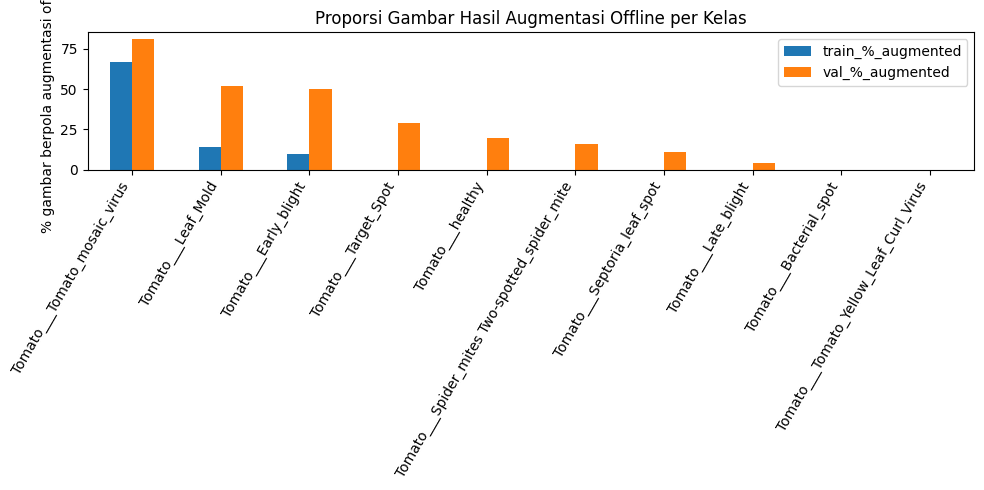

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
df_aug.plot(kind="bar", ax=ax)
ax.set_ylabel("% gambar berpola augmentasi offline")
ax.set_title("Proporsi Gambar Hasil Augmentasi Offline per Kelas")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### Analisis 

Berdasarkan hasil pemeriksaan, ditemukan bahwa proporsi citra yang terindikasi sebagai hasil augmentasi cukup tinggi pada beberapa kelas, baik pada data training maupun validation. Persentase tertinggi terdapat pada kelas **Tomato_mosaic_virus**, yaitu sebesar **66,5% pada training dan 81% pada validation**, diikuti oleh **Leaf_Mold** sebesar **14,4% pada training dan 52% pada validation**, serta **Early_blight** sebesar **10% pada training dan 50% pada validation**.

Temuan tersebut menunjukkan bahwa jumlah **1.000 citra per kelas tidak selalu merepresentasikan 1.000 citra yang sepenuhnya berbeda secara visual**, terutama pada kelas dengan proporsi citra augmented yang tinggi. Dengan demikian, meskipun jumlah data antar kelas terlihat seimbang, keragaman citra asli pada masing-masing kelas belum tentu sama.

Keberadaan citra yang terindikasi sebagai hasil augmentasi pada data training dan validation juga perlu diperhatikan karena dapat menimbulkan potensi **data leakage** apabila citra hasil augmentasi pada validation berasal dari citra sumber yang juga terdapat pada training. Kondisi tersebut dapat menyebabkan data validation memiliki kemiripan yang tinggi dengan data yang telah digunakan selama proses training, sehingga performa validation berpotensi terlihat lebih tinggi dibandingkan kemampuan generalisasi model terhadap data baru.

Namun, hasil pemeriksaan ini **belum secara langsung membuktikan adanya data leakage**. Persentase augmented hanya menunjukkan keberadaan citra yang terindikasi sebagai hasil augmentasi. Untuk memastikan adanya leakage, diperlukan pemeriksaan lebih lanjut terhadap keterkaitan antara citra sumber dan citra hasil augmentasinya pada kedua subset data.

Temuan ini juga menjadi pertimbangan pada tahap preprocessing. Karena sebagian citra telah mengalami augmentasi sebelumnya, augmentasi tambahan pada saat training akan diterapkan secara **ringan hingga sedang** untuk menghindari pemberian transformasi yang terlalu berlebihan pada citra.

Selain itu, kondisi dataset perlu menjadi catatan dalam interpretasi hasil evaluasi. Nilai **Accuracy** atau metrik validation yang tinggi tidak secara langsung dapat diartikan sebagai kemampuan generalisasi yang sempurna apabila masih terdapat kemungkinan kemiripan antara data training dan validation. Oleh karena itu, temuan ini akan dipertimbangkan dalam analisis dan interpretasi hasil model.

## 4. Preprocessing

Tahap preprocessing dilakukan untuk menyiapkan citra agar sesuai dengan kebutuhan model serta mempertimbangkan karakteristik dataset yang telah ditemukan pada tahap EDA. Setiap keputusan preprocessing ditentukan berdasarkan kondisi data dan kebutuhan arsitektur yang digunakan.

| Tahap | Keputusan | Pertimbangan |
|---|---|---|
| **Resize** | 256×256 → 224×224 | Ukuran 224×224 dipilih karena sesuai dengan kebutuhan input MobileNetV2 dan umum digunakan pada model pretrained berbasis ImageNet. Penggunaan ukuran input yang sama juga membuat perbandingan performa antara CNN Custom dan MobileNetV2 lebih konsisten (*apple-to-apple*). Meskipun ukuran 256×256 secara teknis dapat digunakan, ukuran tersebut membutuhkan lebih banyak komputasi dengan peningkatan informasi visual yang relatif kecil. |
| **Normalisasi** | Rescale piksel ke [0,1] untuk CNN Custom; `preprocess_input` untuk MobileNetV2 | CNN Custom menggunakan normalisasi ke rentang [0,1] untuk menjaga skala nilai input tetap konsisten selama proses training. Sementara itu, MobileNetV2 menggunakan `preprocess_input` karena model memanfaatkan bobot pretrained ImageNet yang membutuhkan format preprocessing sesuai dengan konfigurasi saat pretraining. |
| **Augmentasi Online** | Ringan–sedang: rotasi ±20°, horizontal flip, zoom 0.15, shift 0.1, dan perubahan brightness dalam rentang kecil | Hasil EDA menunjukkan adanya citra yang terindikasi telah mengalami augmentasi sebelumnya. Oleh karena itu, augmentasi tambahan diterapkan secara terbatas untuk meningkatkan variasi data dan membantu mengurangi risiko overfitting tanpa menghasilkan transformasi citra yang terlalu berlebihan. |
| **Color Space** | RGB dipertahankan | Seluruh sampel yang diperiksa memiliki mode warna RGB. Informasi warna dipertahankan karena karakteristik warna dapat menjadi informasi visual yang relevan dalam membedakan kondisi atau kelas daun. |
| **Data Split** | Menggunakan folder `train` dan `val` yang tersedia | Dataset telah menyediakan pembagian data menjadi training dan validation. Pembagian tersebut dipertahankan agar struktur dataset tetap konsisten dan tidak dilakukan pembagian ulang secara acak yang dapat mengubah komposisi data yang telah disediakan. |
| **Pelabelan Data** | Label ditentukan berdasarkan nama folder menggunakan `classes=CLASSES` dan direpresentasikan dengan `class_mode="categorical"` | Pelabelan diperlukan agar setiap citra memiliki informasi mengenai kelas yang menjadi target pembelajaran model. Karena dataset terdiri dari 10 kelas, digunakan `class_mode="categorical"` sehingga label direpresentasikan dalam bentuk **one-hot encoding**. Pemetaan antara nama kelas dan indeks numeriknya diperiksa melalui `class_indices` untuk memastikan label setiap kelas konsisten selama proses training dan validasi. |
| **Pengacakan Data** | `shuffle=True` pada data training dan `shuffle=False` pada data validation | Data training diacak agar model tidak mempelajari pola berdasarkan urutan data. Sebaliknya, data validation tidak diacak agar urutan data tetap konsisten selama proses evaluasi dan memudahkan pencocokan antara hasil prediksi dengan label sebenarnya. |

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest",
)


val_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerator siap. Augmentasi HANYA diterapkan pada data train.")

ImageDataGenerator siap. Augmentasi HANYA diterapkan pada data train.


### Pembentukan Subset Dataset

Pada tahap ini digunakan mekanisme `QUICK_DEMO` untuk mengatur jumlah data yang digunakan selama proses eksperimen. Penggunaan mekanisme ini bertujuan untuk **mengurangi waktu komputasi** ketika proses training dilakukan, terutama karena eksperimen dijalankan pada CPU. Apabila seluruh dataset digunakan sejak awal, proses pelatihan dapat membutuhkan waktu yang lebih lama sehingga kurang efisien untuk tahap pengujian dan pengembangan model.

Ketika `QUICK_DEMO` diaktifkan, data akan dibuat menjadi subset dengan mengambil sejumlah gambar secara acak dari setiap kelas. Pengambilan sampel dilakukan secara terpisah pada masing-masing kelas agar jumlah data tetap **proporsional dan representatif**, sehingga tidak ada kelas tertentu yang mendominasi subset. Dengan demikian, model tetap memperoleh data dari seluruh 10 kelas meskipun jumlah gambar yang digunakan lebih sedikit.

Proses pengambilan data menggunakan `seed` yang tetap. Penggunaan `seed` bertujuan untuk menjaga **konsistensi hasil pemilihan sampel**. Dengan seed yang sama, gambar yang terpilih akan tetap sama pada setiap eksekusi sehingga hasil eksperimen lebih mudah dibandingkan dan direproduksi.

Selain itu, digunakan `os.symlink()` untuk membuat subset tanpa menyalin file gambar secara langsung. Pendekatan ini dipilih karena lebih **efisien dalam penggunaan ruang penyimpanan**. File pada folder subset hanya berupa tautan yang mengarah ke file gambar asli, sehingga tidak terjadi duplikasi data secara fisik.

Pada tahap pengujian utama, `QUICK_DEMO` tidak digunakan sehingga seluruh dataset tetap dipertahankan. Hal ini dilakukan agar model dapat dilatih menggunakan **seluruh data yang tersedia** sehingga hasil pelatihan dan evaluasi dapat menggambarkan performa model secara lebih optimal. Berdasarkan output program, direktori yang digunakan adalah:

- **Data training:** `/kaggle/input/datasets/kaustubh999/tomatoleaf/tomato/train`
- **Data validasi:** `/kaggle/input/datasets/kaustubh999/tomatoleaf/tomato/val`

Dengan demikian, `QUICK_DEMO` digunakan terutama untuk **efisiensi pada tahap pengembangan dan pengujian awal**, sedangkan pada eksperimen utama seluruh dataset digunakan untuk memperoleh hasil yang lebih representatif.

In [14]:
import shutil

def build_subset_dir(src_dir, dst_dir, n_per_class):
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    dst_dir.mkdir(parents=True)
    for cls in CLASSES:
        files = list((src_dir/cls).glob("*"))
        random.Random(SEED).shuffle(files)
        chosen = files[:n_per_class] if n_per_class else files
        cls_dst = dst_dir/cls
        cls_dst.mkdir()
        for f in chosen:
            os.symlink(f.resolve(), cls_dst/f.name)
    return dst_dir

if QUICK_DEMO:
    train_use_dir = build_subset_dir(TRAIN_DIR, Path("tomato_subset_train"), SAMPLES_PER_CLASS_TRAIN)
    val_use_dir = build_subset_dir(VAL_DIR, Path("tomato_subset_val"), SAMPLES_PER_CLASS_VAL)
else:
    train_use_dir = TRAIN_DIR
    val_use_dir = VAL_DIR

print("Train dir dipakai:", train_use_dir)
print("Val dir dipakai:", val_use_dir)

Train dir dipakai: /kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/train
Val dir dipakai: /kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/val


In [15]:
train_generator = train_datagen.flow_from_directory(
    train_use_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASSES,
    shuffle=True,
    seed=SEED,
)

val_generator = val_datagen.flow_from_directory(
    val_use_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASSES,
    shuffle=False,
)

print("Label mapping:", train_generator.class_indices)

Found 10000 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.
Label mapping: {'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


## 5. Arsitektur CNN Kustom

Perancangan arsitektur disesuaikan dengan karakteristik permasalahan, yaitu klasifikasi citra daun tomat ke dalam **10 kelas** dengan karakteristik visual antar kelas yang pada beberapa kondisi memiliki kemiripan. Oleh karena itu, model tidak hanya perlu mampu mengenali karakteristik sederhana seperti warna dan tepi daun, tetapi juga perlu mempelajari pola tekstur, bentuk, serta karakteristik bercak atau gejala penyakit yang lebih kompleks.

Arsitektur yang digunakan terdiri atas **empat blok konvolusi**. Setiap blok memiliki dua lapisan `Conv2D` berukuran kernel 3×3 yang masing-masing diikuti oleh `BatchNormalization` dan aktivasi `ReLU`, kemudian diakhiri dengan `MaxPooling2D` berukuran 2×2. Jumlah filter ditingkatkan secara bertahap dari **32, 64, 128 hingga 256**. Setelah seluruh blok konvolusi, digunakan `GlobalAveragePooling2D`, kemudian dilanjutkan dengan `Dense(128)`, `Dropout(0.4)`, dan lapisan output `Dense(10)` dengan aktivasi `softmax`.

Pemilihan setiap komponen dilakukan dengan mempertimbangkan kebutuhan model terhadap kemampuan ekstraksi fitur, efisiensi komputasi, serta pengendalian overfitting.

| Komponen | Pilihan | Alasan |
|---|---|---|
| **Jumlah blok konvolusi** | 4 blok dengan total 8 lapisan `Conv2D` | Empat blok dipilih agar model memiliki kedalaman yang cukup untuk mempelajari fitur secara bertahap dari pola sederhana hingga pola yang lebih kompleks. Pada blok awal, model dapat mempelajari karakteristik dasar seperti tepi, bentuk, dan pola warna, sedangkan blok yang lebih dalam dapat menangkap kombinasi fitur yang lebih kompleks seperti tekstur dan pola bercak pada daun. Jumlah empat blok juga memberikan kapasitas representasi yang lebih besar tetapi tetap lebih sederhana dan ringan dibandingkan backbone pretrained yang jauh lebih dalam. |
| **Dua `Conv2D` pada setiap blok** | 2 lapisan `Conv2D` 3×3 sebelum `MaxPooling2D` | Dua lapisan konvolusi berturut-turut agar model melakukan ekstraksi fitur secara bertahap sebelum resolusi spasial dikurangi. Lapisan pertama dapat menangkap pola lokal, kemudian lapisan berikutnya mengolah kombinasi pola tersebut menjadi representasi yang lebih kompleks. Pendekatan ini juga meningkatkan jumlah transformasi non-linear melalui aktivasi `ReLU`, sehingga kemampuan representasi model menjadi lebih kaya tanpa harus menggunakan kernel berukuran besar. |
| **Kernel konvolusi** | 3×3 pada seluruh lapisan konvolusi | Kernel 3×3 dipilih karena mampu menangkap pola lokal seperti tepi, tekstur, dan struktur bercak pada daun dengan jumlah parameter yang relatif efisien. Penggunaan ukuran kernel yang sama pada seluruh blok juga membuat arsitektur lebih sederhana dan konsisten. |
| **Jumlah filter** | 32 → 64 → 128 → 256 | Jumlah filter ditingkatkan secara bertahap mengikuti kedalaman jaringan. Semakin dalam lapisan, semakin kompleks representasi fitur sehingga diperlukan lebih banyak filter untuk menangkap berbagai pola yang berbeda. Peningkatan jumlah filter ini memungkinkan model mempelajari karakteristik visual penyakit secara lebih detail. |
| **Padding** | `padding="same"` | Padding `same` digunakan agar ukuran spasial citra tetap dipertahankan setelah proses konvolusi. Dengan demikian, informasi pada bagian tepi citra tetap dapat diproses dan ukuran feature map tidak berkurang sebelum proses pooling dilakukan. Hal ini membantu menjaga informasi spasial, terutama pada tahap awal ketika fitur dasar sedang diekstraksi. |
| **Batch Normalization** | Setelah setiap `Conv2D`, sebelum `ReLU` | `BatchNormalization` digunakan untuk menstabilkan distribusi aktivasi selama proses training. Dengan distribusi aktivasi yang lebih terkontrol, proses optimasi dapat berjalan lebih stabil dan model dapat mencapai konvergensi dengan lebih mudah. Penggunaannya setelah setiap konvolusi juga memberikan pola arsitektur yang konsisten pada seluruh blok. |
| **Aktivasi** | `ReLU` | ReLU digunakan pada setiap lapisan tersembunyi karena memberikan fungsi non-linear yang sederhana dan efisien secara komputasi. Non-linearitas diperlukan agar jaringan dapat mempelajari hubungan yang kompleks antara fitur visual dan kelas. ReLU juga membantu mengurangi masalah saturasi yang lebih umum terjadi pada fungsi aktivasi seperti sigmoid atau tanh. |
| **Max Pooling** | `MaxPooling2D(2×2)` setelah setiap blok | Max pooling digunakan untuk melakukan downsampling terhadap feature map sehingga ukuran spasial dan beban komputasi dapat dikurangi secara bertahap. Operasi ini mempertahankan respons fitur yang paling kuat pada setiap area lokal sehingga informasi fitur yang dianggap paling menonjol tetap dipertahankan. |
| **Peningkatan filter + pooling bertahap** | Filter meningkat 32 → 256 dan resolusi spasial berkurang secara bertahap | Ketika ukuran feature map semakin kecil akibat pooling, jumlah filter ditingkatkan untuk menyediakan kapasitas yang lebih besar dalam merepresentasikan fitur yang semakin kompleks. Dengan demikian, model tidak hanya mengandalkan informasi piksel, tetapi secara bertahap membentuk representasi tingkat tinggi. |
| **Global Average Pooling** | `GlobalAveragePooling2D()` | Global Average Pooling digunakan untuk mengubah feature map menjadi representasi satu dimensi tanpa menggunakan `Flatten` yang dapat menghasilkan jumlah fitur sangat besar. Penggunaan GAP mengurangi jumlah parameter pada bagian classifier sehingga risiko overfitting dapat ditekan. Hal ini menjadi pertimbangan penting karena model dilatih untuk membedakan 10 kelas dan memiliki kemungkinan mempelajari pola spesifik pada data training jika classifier terlalu besar. |
| **Dense layer** | `Dense(128, activation="relu")` | Setelah GAP, digunakan satu lapisan Dense dengan 128 unit untuk mengolah representasi fitur yang telah diringkas dan menggabungkan berbagai fitur sebelum proses klasifikasi. Jumlah 128 unit dipilih sebagai kapasitas menengah sehingga classifier tetap memiliki kemampuan untuk memisahkan 10 kelas tanpa menambahkan terlalu banyak parameter. |
| **Dropout** | `Dropout(0.4)` | Dropout digunakan sebagai regularisasi dengan menonaktifkan sebagian unit secara acak selama training. Nilai 0.4 berarti sekitar 40% unit pada lapisan tersebut dinonaktifkan pada setiap iterasi. |
| **Output layer** | `Dense(10, activation="softmax")` | Lapisan output memiliki 10 unit karena dataset terdiri atas 10 kelas. Aktivasi softmax digunakan untuk menghasilkan distribusi probabilitas pada seluruh kelas. Setiap citra kemudian memperoleh probabilitas untuk masing-masing kelas dan kelas dengan probabilitas tertinggi digunakan sebagai hasil prediksi. Penggunaan softmax sesuai dengan permasalahan klasifikasi **multiclass single-label**, di mana satu citra hanya memiliki satu kelas target. |
| **Optimizer** | Adam, learning rate = 0.001 | Adam digunakan karena merupakan optimizer adaptif yang menyesuaikan besar langkah pembaruan parameter berdasarkan informasi gradien selama training. Learning rate 0.001 digunakan sebagai nilai awal yang umum untuk optimizer Adam dan memberikan kompromi antara kecepatan konvergensi dan kestabilan proses pembelajaran. |
| **Loss function** | `categorical_crossentropy` | Fungsi loss ini digunakan karena target label direpresentasikan dalam bentuk categorical/one-hot encoding dan model menghasilkan probabilitas menggunakan softmax. Loss menghitung perbedaan antara distribusi probabilitas prediksi model dengan label sebenarnya, sehingga memberikan sinyal yang sesuai untuk mengoptimalkan klasifikasi 10 kelas. |
| **Metric** | `accuracy` | Accuracy digunakan sebagai metrik selama proses training untuk melihat proporsi prediksi yang sesuai dengan label sebenarnya. Metrik ini memberikan gambaran langsung mengenai kemampuan model dalam melakukan klasifikasi terhadap data yang digunakan. |

### Alur Arsitektur

Secara keseluruhan, alur model sebagai berikut:

**Input 224×224×3 → Blok Konvolusi 1 (32 filter) → MaxPooling → Blok Konvolusi 2 (64 filter) → MaxPooling → Blok Konvolusi 3 (128 filter) → MaxPooling → Blok Konvolusi 4 (256 filter) → MaxPooling → Global Average Pooling → Dense 128 → Dropout 0.4 → Dense 10 + Softmax**

Setiap blok konvolusi memiliki pola yang sama, yaitu dua kali proses `Conv2D → BatchNormalization → ReLU`, kemudian dilanjutkan dengan `MaxPooling2D`. Struktur tersebut dirancang agar ekstraksi fitur dilakukan secara bertahap. Pada bagian awal jaringan, model berfokus pada fitur visual sederhana, sedangkan semakin dalam jaringan, fitur yang dipelajari menjadi semakin abstrak dan kompleks.

Penggunaan `GlobalAveragePooling2D` sebelum bagian classifier juga membuat jumlah parameter pada bagian akhir jaringan lebih terkendali. Setelah representasi fitur diringkas, `Dense(128)` digunakan untuk melakukan pemrosesan akhir sebelum prediksi kelas. `Dropout(0.4)` kemudian memberikan regularisasi tambahan, sedangkan `Dense(10, softmax)` menghasilkan probabilitas untuk masing-masing kelas.

Dengan rancangan tersebut, CNN kustom diharapkan mampu memberikan **kapasitas ekstraksi fitur yang cukup untuk membedakan karakteristik visual dari 10 kelas**, namun tetap mempertahankan struktur yang relatif sederhana dan dapat dilatih tanpa bergantung pada bobot pretrained. Arsitektur ini selanjutnya dapat digunakan sebagai **baseline atau model pembanding** terhadap MobileNetV2 untuk melihat sejauh mana penggunaan arsitektur kustom dibandingkan dengan model pretrained memengaruhi performa klasifikasi.

In [16]:
def build_custom_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Blok 1: 32 filter
    x = layers.Conv2D(32, (3,3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, (3,3), padding="same")(x)
    x = layers.BatchNormalization(0,9)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Blok 2: 64 filter
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization(0,9)(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization(0,9)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Blok 3: 128 filter
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Blok 4: 256 filter
    x = layers.Conv2D(256, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="CustomCNN_TomatoLeaf")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

custom_model = build_custom_cnn(IMG_SIZE + (3,), NUM_CLASSES)
custom_model.summary()

I0000 00:00:1787205225.839342      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787205225.842900      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CustomCNN_TomatoLeaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 1,210,282 (4.62 MB)

 Trainable params: 1,208,362 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 6. Training CNN Kustom

Setelah arsitektur CNN kustom ditentukan, model dilatih menggunakan data training dan dievaluasi pada data validation pada setiap epoch. Proses training dilakukan secara iteratif hingga mencapai jumlah epoch yang telah ditentukan. Namun, jumlah epoch yang besar tidak selalu menghasilkan model yang lebih baik karena model dapat mulai mempelajari karakteristik spesifik pada data training dan mengalami **overfitting**. Oleh karena itu, proses training dilengkapi dengan beberapa callback untuk mengontrol proses pembelajaran berdasarkan performa model pada data validation.

Tiga callback yang digunakan adalah `EarlyStopping`, `ModelCheckpoint`, dan `ReduceLROnPlateau`. Ketiganya memiliki fungsi yang berbeda tetapi saling melengkapi dalam menjaga proses training agar tetap efisien dan menghasilkan bobot model yang memiliki performa validasi terbaik.

| Callback | Konfigurasi | Alasan Penggunaan |
|---|---|---|
| **EarlyStopping** | `monitor="val_loss"`, `patience=5`, `restore_best_weights=True` | `EarlyStopping` digunakan untuk menghentikan proses training ketika performa model pada data validation tidak lagi menunjukkan perbaikan. Parameter `val_loss` dipilih sebagai indikator karena loss menunjukkan seberapa besar kesalahan prediksi model terhadap label sebenarnya. Penggunaan `patience=5` ini diperlukan karena peningkatan performa tidak selalu terjadi pada setiap epoch secara langsung. Selain itu, `restore_best_weights=True` digunakan agar setelah training dihentikan, bobot model dikembalikan ke kondisi pada epoch dengan nilai `val_loss` terbaik, bukan menggunakan bobot pada epoch terakhir. Dengan demikian, model akhir tidak menggunakan bobot yang berpotensi sudah mengalami overfitting. |
| **ModelCheckpoint** | `monitor="val_accuracy"`, `save_best_only=True` | `ModelCheckpoint` digunakan untuk menyimpan model dengan performa validasi terbaik selama proses training. Parameter `val_accuracy` digunakan karena accuracy merupakan metrik utama yang menunjukkan proporsi prediksi yang benar pada data validation. Dengan `save_best_only=True`, hanya model yang menghasilkan `val_accuracy` lebih tinggi dibandingkan epoch sebelumnya yang disimpan. Hal ini penting karena epoch terakhir belum tentu menghasilkan performa terbaik. Bobot terbaik kemudian dapat digunakan kembali untuk proses evaluasi tanpa harus bergantung pada kondisi model di akhir training. |
| **ReduceLROnPlateau** | `monitor="val_loss"`, `factor=0.5`, `patience=2`, `min_lr=1e-6` | `ReduceLROnPlateau` digunakan untuk menyesuaikan learning rate ketika proses pembelajaran mulai mengalami stagnasi. Parameter `val_loss` digunakan untuk mendeteksi kondisi ketika performa validasi tidak lagi membaik. Jika kondisi tersebut berlangsung selama dua epoch (`patience=2`), learning rate akan dikurangi menjadi 50% dari nilai sebelumnya melalui `factor=0.5`. Penurunan learning rate memungkinkan model melakukan pembaruan bobot dengan langkah yang lebih kecil sehingga dapat melakukan optimasi secara lebih halus ketika mendekati kondisi optimum. Batas `min_lr=1e-6` digunakan agar learning rate tidak turun terlalu kecil sehingga proses pembelajaran tetap dapat berlangsung. |

Ketiga callback tersebut digunakan secara bersamaan karena masing-masing menangani aspek yang berbeda dalam proses training. `ReduceLROnPlateau` berperan sebagai mekanisme **penyesuaian proses pembelajaran** ketika validasi mulai stagnan. Jika penurunan learning rate masih belum menghasilkan perbaikan, `EarlyStopping` dapat menghentikan training setelah kondisi tersebut berlangsung lebih lama. Sementara itu, `ModelCheckpoint` memastikan bahwa model dengan performa validasi terbaik tetap tersimpan selama proses training.

Pada implementasinya, model dilatih menggunakan `train_generator` dan dievaluasi pada `val_generator` untuk setiap epoch. Jumlah epoch ditentukan melalui parameter `EPOCHS_CUSTOM`, tetapi proses aktual training dapat berhenti lebih awal apabila kondisi `EarlyStopping` terpenuhi. Dengan pendekatan ini, jumlah epoch maksimum tidak harus selalu dicapai karena proses training dikendalikan berdasarkan perkembangan performa pada data validation.

In [17]:
checkpoint_path = "/kaggle/working/best_custom_cnn.keras"

cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history_custom = custom_model.fit(
    train_generator,
    epochs=EPOCHS_CUSTOM,
    validation_data=val_generator,
    callbacks=cb_list,
    verbose=2,
)

Epoch 1/40


2026-08-20 05:54:03.614479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 05:54:03.769033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 05:54:06.909745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 05:54:07.215239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787205256.854996     149 device_compiler.h:196]

313/313 - 254s - 813ms/step - accuracy: 0.6144 - loss: 1.1274 - val_accuracy: 0.1100 - val_loss: 6.6746 - learning_rate: 0.0010
Epoch 2/40
313/313 - 163s - 520ms/step - accuracy: 0.7583 - loss: 0.7046 - val_accuracy: 0.4550 - val_loss: 4.1339 - learning_rate: 0.0010
Epoch 3/40
313/313 - 162s - 517ms/step - accuracy: 0.7968 - loss: 0.5998 - val_accuracy: 0.4530 - val_loss: 2.5999 - learning_rate: 0.0010
Epoch 4/40
313/313 - 164s - 523ms/step - accuracy: 0.8266 - loss: 0.5149 - val_accuracy: 0.4800 - val_loss: 2.4457 - learning_rate: 0.0010
Epoch 5/40
313/313 - 165s - 528ms/step - accuracy: 0.8485 - loss: 0.4385 - val_accuracy: 0.2870 - val_loss: 6.6667 - learning_rate: 0.0010
Epoch 6/40
313/313 - 161s - 516ms/step - accuracy: 0.8730 - loss: 0.3758 - val_accuracy: 0.8830 - val_loss: 0.3273 - learning_rate: 0.0010
Epoch 7/40
313/313 - 164s - 523ms/step - accuracy: 0.8827 - loss: 0.3579 - val_accuracy: 0.9170 - val_loss: 0.2472 - learning_rate: 0.0010
Epoch 8/40
313/313 - 164s - 523ms/step

Epoch 4/4


19/19 - 43s - 2s/step - accuracy: 0.6250 - loss: 1.1174 - val_accuracy: 0.0933 - val_loss: 4.2377 - learning_rate: 5.0000e-04


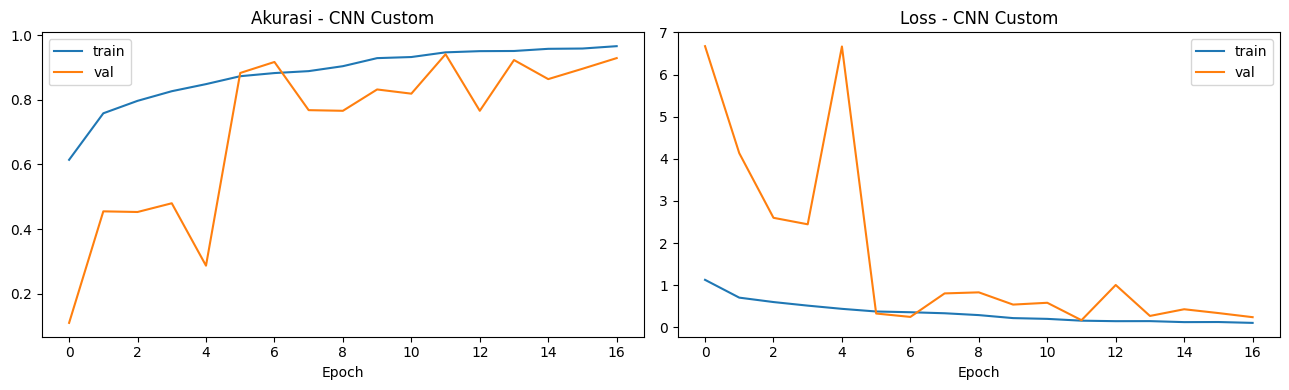

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(history_custom.history["accuracy"], label="train")
axes[0].plot(history_custom.history["val_accuracy"], label="val")
axes[0].set_title("Akurasi - CNN Custom")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history_custom.history["loss"], label="train")
axes[1].plot(history_custom.history["val_loss"], label="val")
axes[1].set_title("Loss - CNN Custom")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

In [19]:
final_train_acc = history_custom.history["accuracy"][-1]
final_val_acc = history_custom.history["val_accuracy"][-1]
print(f"Train accuracy akhir: {final_train_acc:.3f} | Val accuracy akhir: {final_val_acc:.3f}")

Train accuracy akhir: 0.966 | Val accuracy akhir: 0.929


### Analisis Hasil

Berdasarkan kurva training, CNN kustom menunjukkan kemampuan belajar yang baik, meskipun performa validation masih mengalami fluktuasi.

**a. Analisis Akurasi**

Akurasi training meningkat dari sekitar **61%** pada epoch pertama hingga **96,6%** pada epoch terakhir. Sementara itu, akurasi validation meningkat hingga sekitar **94%**, tetapi sempat turun cukup tajam sebelum kembali meningkat. Pada akhir training, validation accuracy mencapai **92,9%**.

Selisih akurasi akhir antara training dan validation adalah sekitar **3,7 poin persentase**. Nilai ini masih relatif kecil sehingga menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik dan belum mengalami overfitting yang berat. Namun, fluktuasi validation accuracy menunjukkan bahwa performa model masih belum sepenuhnya stabil.

**b. Analisis Loss**

*Training loss* menurun konsisten dari sekitar **1,1** menjadi **0,1**, menunjukkan bahwa model semakin baik dalam mempelajari data training. Sebaliknya, *validation loss* mengalami fluktuasi cukup besar, terutama pada awal training, sebelum akhirnya menurun ke tingkat yang lebih rendah.

Kondisi ini menunjukkan bahwa model mampu belajar dengan baik, tetapi prediksinya terhadap data validation masih sensitif terhadap perubahan bobot. Oleh karena itu, `val_loss` tetap penting sebagai indikator dalam proses training.

**c. Indikasi Overfitting dan Callback**

Terdapat **indikasi overfitting ringan**, karena training accuracy lebih tinggi daripada validation accuracy. Namun, *validation loss* tidak terus meningkat dan validation accuracy akhir masih mencapai **92,9%**, sehingga belum menunjukkan overfitting yang parah.

Penggunaan `ReduceLROnPlateau`, `EarlyStopping`, dan `ModelCheckpoint` menjadi relevan. `ReduceLROnPlateau` membantu menstabilkan optimasi, `EarlyStopping` mencegah training berlebihan, sedangkan `ModelCheckpoint` memastikan model dengan performa validation terbaik tetap tersimpan karena **epoch terakhir belum tentu merupakan epoch terbaik**.

**d. Kesimpulan**

Secara keseluruhan, CNN kustom memiliki performa yang cukup baik dengan **training accuracy 96,6%** dan **validation accuracy 92,9%**. Model mampu mempelajari fitur visual dengan baik dan memiliki generalisasi yang cukup baik, meskipun validation masih fluktuatif. Oleh karena itu, evaluasi selanjutnya perlu menggunakan **precision, recall, F1-score, dan confusion matrix**, serta membandingkan hasilnya dengan **MobileNetV2**.


## 7. Evaluasi CNN Kustom

Evaluasi CNN kustom dilakukan menggunakan dua metrik utama, yaitu **Accuracy** dan **F1 Score**. Accuracy digunakan untuk mengukur proporsi prediksi yang benar terhadap seluruh data, sedangkan **F1 Score macro-average** digunakan untuk menilai performa model pada masing-masing dari 10 kelas secara seimbang.

Penggunaan F1 Score sebagai metrik pelengkap Accuracy penting karena nilai macro-average memberikan bobot yang sama pada setiap kelas. Dengan demikian, performa yang kurang baik pada kelas tertentu tetap dapat terlihat meskipun Accuracy secara keseluruhan tinggi. Hal ini relevan karena beberapa kelas pada dataset memiliki karakteristik gejala visual yang serupa dan berpotensi menyebabkan kesalahan klasifikasi.


=== CNN Custom ===
Accuracy      : 0.9410
F1 Score (macro)   : 0.9409
F1 Score (weighted): 0.9409

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.93      0.99      0.96       100
                        Tomato___Early_blight       0.92      0.95      0.94       100
                         Tomato___Late_blight       0.90      0.99      0.94       100
                           Tomato___Leaf_Mold       0.99      0.88      0.93       100
                  Tomato___Septoria_leaf_spot       0.97      0.93      0.95       100
Tomato___Spider_mites Two-spotted_spider_mite       0.89      0.89      0.89       100
                         Tomato___Target_Spot       0.94      0.94      0.94       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.87      0.93       100
                 Tomato___Tomato_mosaic_virus       1.00      0.97      0.98       100
                             T

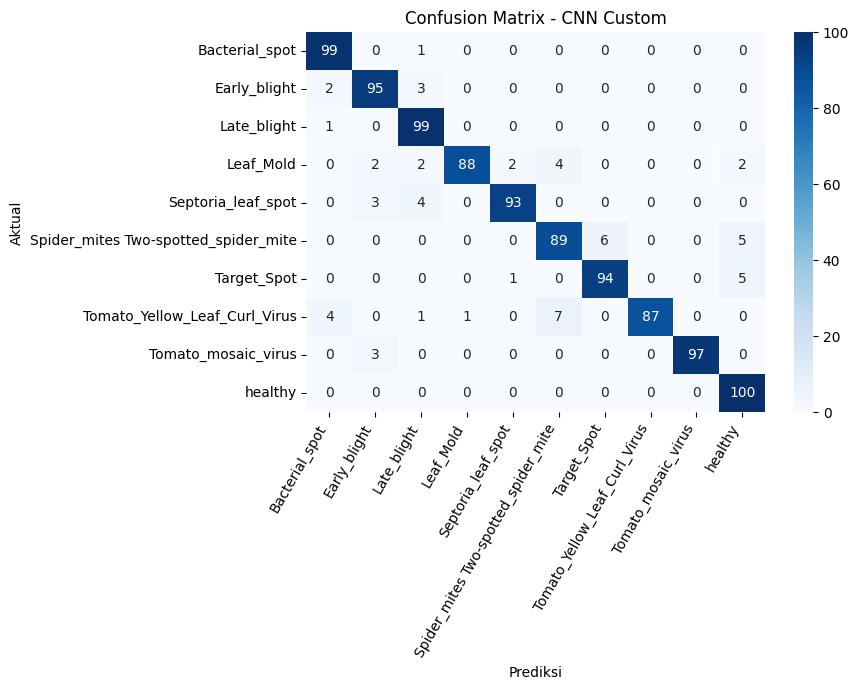

In [21]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_true = generator.classes
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"=== {model_name} ===")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 Score (macro)   : {f1_macro:.4f}")
    print(f"F1 Score (weighted): {f1_weighted:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[c.replace("Tomato___","") for c in CLASSES],
                yticklabels=[c.replace("Tomato___","") for c in CLASSES])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prediksi"); plt.ylabel("Aktual")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

results_custom = evaluate_model(custom_model, val_generator, "CNN Custom")

### Analisis Hasil Evaluasi

Berdasarkan hasil evaluasi pada data uji, CNN kustom memperoleh **Accuracy sebesar 94,10%** dan **F1 Score macro sebesar 94,09%**. Nilai F1 Score macro yang hampir sama dengan Accuracy menunjukkan bahwa model memiliki performa yang relatif seimbang pada seluruh 10 kelas dan tidak terlalu dipengaruhi oleh performa satu kelas tertentu.

**a. Analisis Per Kelas**

Sebagian besar kelas memperoleh **F1 Score di atas 0,93**, menunjukkan kemampuan klasifikasi yang baik. Performa terbaik terdapat pada **Tomato_mosaic_virus** dengan F1 Score **0,98**, serta **Bacterial_spot** dengan **0,96**. Kelas **healthy** juga memiliki recall **1,00**, yang berarti seluruh citra sehat berhasil dikenali sebagai kelas healthy.

Beberapa kelas masih memiliki performa yang relatif lebih rendah. **Spider_mites** memperoleh F1 Score **0,89**, sedangkan **Leaf_Mold** dan **Tomato_Yellow_Leaf_Curl_Virus** masing-masing memperoleh F1 Score **0,93**. Pada Leaf_Mold, recall hanya **0,88**, sedangkan pada Tomato_Yellow_Leaf_Curl_Virus recall sebesar **0,87**. Hal ini menunjukkan bahwa sebagian citra dari kedua kelas tersebut masih diklasifikasikan ke kelas lain.

**b. Analisis Confusion Matrix**

Confusion matrix menunjukkan bahwa sebagian besar prediksi berada pada diagonal utama, sehingga model mampu membedakan mayoritas kelas dengan baik. Kesalahan klasifikasi paling terlihat pada **Leaf_Mold**, yang beberapa sampelnya diprediksi sebagai **Spider_mites**, **Early_blight**, **Late_blight**, dan **healthy**.

Pada **Tomato_Yellow_Leaf_Curl_Virus**, beberapa sampel salah diklasifikasikan sebagai **Bacterial_spot** dan terutama **Spider_mites**. Sementara itu, **Early_blight** dan **Septoria_leaf_spot** juga menunjukkan beberapa kesalahan klasifikasi satu sama lain atau terhadap kelas penyakit lain. Pola tersebut menunjukkan bahwa kemiripan karakteristik visual antar gejala menjadi salah satu sumber kesalahan model.

**c. Kesimpulan**

Secara keseluruhan, CNN kustom menunjukkan performa klasifikasi yang **baik dan cukup seimbang**, dengan **Accuracy 94,10%** dan **F1 Score macro 94,09%**. Model memiliki kemampuan sangat baik pada beberapa kelas, tetapi masih mengalami kesulitan pada kelas dengan karakteristik visual yang lebih mirip, terutama **Spider_mites, Leaf_Mold, dan Tomato_Yellow_Leaf_Curl_Virus**. Hasil ini dapat digunakan sebagai acuan untuk membandingkan performa CNN kustom dengan **MobileNetV2** pada tahap eksperimen berikutnya.


## 8. Transfer Learning — MobileNetV2

Setelah CNN kustom selesai dilatih dan dievaluasi, Selanjutnya menggunakan **MobileNetV2** dengan pendekatan *transfer learning*. MobileNetV2 dipilih karena memiliki arsitektur yang relatif ringan dan efisien dibandingkan backbone yang lebih besar seperti VGG16 atau ResNet50. Hal ini sesuai dengan tujuan pengembangan model klasifikasi penyakit tanaman yang tidak hanya mempertimbangkan performa, tetapi juga efisiensi komputasi sehingga berpotensi diterapkan pada perangkat dengan sumber daya terbatas seperti *mobile* atau *edge device*.

MobileNetV2 menggunakan **depthwise separable convolution** yang mengurangi jumlah parameter dan operasi komputasi tanpa menghilangkan kemampuan model dalam mengekstraksi fitur visual. Selain itu, pemilihan MobileNetV2 memberikan pembanding yang lebih seimbang terhadap CNN kustom yang juga dirancang sebagai model relatif ringan. Dengan demikian, perbandingan yang dilakukan tidak hanya menunjukkan perbedaan antara model kustom dan model *pretrained*, tetapi juga membandingkan dua pendekatan dengan pertimbangan efisiensi yang serupa.

Strategi *transfer learning* yang digunakan adalah menggunakan MobileNetV2 dengan bobot **ImageNet** sebagai *feature extractor*. Bagian classifier bawaan MobileNetV2 tidak digunakan karena model perlu disesuaikan dengan 10 kelas pada dataset daun tomat. Konfigurasi utama yang digunakan adalah sebagai berikut:

| Komponen                   | Konfigurasi                                          | Alasan Penggunaan                                                                                                                                                                                                                                              |
| -------------------------- | ---------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Base Model**             | `MobileNetV2(weights="imagenet", include_top=False)` | Bobot ImageNet digunakan karena telah mempelajari berbagai fitur visual umum seperti tepi, tekstur, bentuk, dan pola. `include_top=False` digunakan agar classifier bawaan ImageNet dapat digantikan dengan classifier yang sesuai untuk 10 kelas daun tomat.  |
| **Freeze Base Model**      | `base_model.trainable = False`                       | Seluruh bobot MobileNetV2 dibekukan sehingga tidak diperbarui selama training awal. Strategi ini mengurangi jumlah parameter yang harus dilatih dan risiko overfitting, terutama karena dataset yang digunakan jauh lebih kecil dibandingkan dataset ImageNet. |
| **Global Average Pooling** | `GlobalAveragePooling2D()`                           | Digunakan untuk mengubah feature map menjadi representasi fitur yang lebih ringkas. Layer ini juga mengurangi jumlah parameter dibandingkan `Flatten`, sehingga model menjadi lebih ringan dan risiko overfitting dapat ditekan.                               |
| **Dense Layer**            | `Dense(128, activation="relu")`                      | Digunakan sebagai classifier tambahan untuk mempelajari hubungan antara fitur yang diekstraksi MobileNetV2 dengan karakteristik khusus pada citra daun tomat.                                                                                                  |
| **Dropout**                | `Dropout(0.4)`                                       | Digunakan untuk mengurangi risiko overfitting dengan menonaktifkan sebagian neuron secara acak selama training sehingga model tidak terlalu bergantung pada fitur tertentu.                                                                                    |
| **Output Layer**           | `Dense(num_classes, activation="softmax")`           | Menghasilkan probabilitas untuk masing-masing dari 10 kelas sehingga model dapat menentukan kelas dengan probabilitas tertinggi.                                                                                                                               |
| **Optimizer**              | `Adam(learning_rate=0.001)`                          | Adam digunakan karena mampu melakukan pembaruan bobot secara adaptif dan sesuai untuk proses training classifier baru.                                                                                                                                         |
| **Loss Function**          | `categorical_crossentropy`                           | Digunakan karena permasalahan yang dihadapi merupakan klasifikasi multikelas dengan label berbentuk *one-hot encoding*.                                                                                                                                        |

Pada tahap ini, hanya **classifier head** yang dilatih, sedangkan bobot MobileNetV2 tetap menggunakan hasil *pretraining* ImageNet. Pendekatan tersebut dipilih karena fitur visual yang telah dipelajari pada ImageNet masih relevan sebagai fitur dasar untuk citra daun, seperti bentuk, tekstur, dan pola. Melatih seluruh backbone dari awal akan membutuhkan lebih banyak data dan berpotensi meningkatkan risiko overfitting.

Secara keseluruhan, pendekatan ini digunakan untuk memperoleh model yang memanfaatkan **pengetahuan visual dari model pretrained**, tetapi tetap memiliki classifier yang disesuaikan dengan dataset daun tomat. Hasil MobileNetV2 kemudian dapat dibandingkan dengan CNN kustom berdasarkan **Accuracy dan F1 Score**, sehingga dapat diketahui apakah penggunaan *transfer learning* memberikan peningkatan performa sekaligus mempertahankan efisiensi model.


In [22]:
def build_transfer_model(input_shape, num_classes):
    global TRANSFER_LEARNING_IS_REAL
    try:
        base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
        TRANSFER_LEARNING_IS_REAL = True
        print("Bobot ImageNet berhasil dimuat.")
    except Exception as e:
        print("gagal mengunduh bobot ImageNet.")
        base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights=None)
        TRANSFER_LEARNING_IS_REAL = False

    base_model.trainable = False  

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_Transfer_TomatoLeaf")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

TRANSFER_LEARNING_IS_REAL = None
transfer_model = build_transfer_model(IMG_SIZE + (3,), NUM_CLASSES)
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Bobot ImageNet berhasil dimuat -- transfer learning berjalan sesungguhnya.


Model: "MobileNetV2_Transfer_TomatoLeaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Preprocessing  transfer learning:** MobileNetV2 butuh normalisasi sesuai skema saat dilatih di ImageNet (skala [-1, 1], bukan [0, 1] seperti CNN custom). Karena itu dipakai `ImageDataGenerator` terpisah dengan `preprocessing_function=mobilenet_preprocess`, augmentasinya tetap sama (ringan-sedang) supaya perbandingan adil dengan CNN custom.

In [23]:
transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest",
)
transfer_val_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

transfer_train_gen = transfer_train_datagen.flow_from_directory(
    train_use_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASSES, shuffle=True, seed=SEED,
)
transfer_val_gen = transfer_val_datagen.flow_from_directory(
    val_use_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASSES, shuffle=False,
)

Found 10000 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.


In [24]:
transfer_checkpoint_path = "/kaggle/working/best_transfer_model.keras"

cb_list_transfer = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ModelCheckpoint(transfer_checkpoint_path, monitor="val_accuracy", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history_transfer = transfer_model.fit(
    transfer_train_gen,
    epochs=EPOCHS_TRANSFER,
    validation_data=transfer_val_gen,
    callbacks=cb_list_transfer,
    verbose=2,
)

Epoch 1/20


2026-08-20 06:43:10.925727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 06:43:11.067289: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 06:43:11.205419: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 06:44:21.344009: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-20 06:44:21.481257: E external/local_xla/xla/stream_

313/313 - 203s - 649ms/step - accuracy: 0.6615 - loss: 1.0076 - val_accuracy: 0.8150 - val_loss: 0.5867 - learning_rate: 0.0010
Epoch 2/20
313/313 - 156s - 497ms/step - accuracy: 0.7933 - loss: 0.6057 - val_accuracy: 0.8250 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 3/20
313/313 - 157s - 502ms/step - accuracy: 0.8234 - loss: 0.5222 - val_accuracy: 0.8410 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 4/20
313/313 - 154s - 493ms/step - accuracy: 0.8430 - loss: 0.4629 - val_accuracy: 0.8300 - val_loss: 0.4951 - learning_rate: 0.0010
Epoch 5/20
313/313 - 156s - 500ms/step - accuracy: 0.8572 - loss: 0.4276 - val_accuracy: 0.8480 - val_loss: 0.4254 - learning_rate: 0.0010
Epoch 6/20
313/313 - 155s - 496ms/step - accuracy: 0.8590 - loss: 0.4134 - val_accuracy: 0.8530 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 7/20
313/313 - 157s - 503ms/step - accuracy: 0.8715 - loss: 0.3822 - val_accuracy: 0.8560 - val_loss: 0.4046 - learning_rate: 0.0010
Epoch 8/20
313/313 - 156s - 499ms/step

19/19 - 9s - 458ms/step - accuracy: 0.0933 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026 - learning_rate: 0.0010


Epoch 3/3


19/19 - 5s - 271ms/step - accuracy: 0.1050 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026 - learning_rate: 0.0010


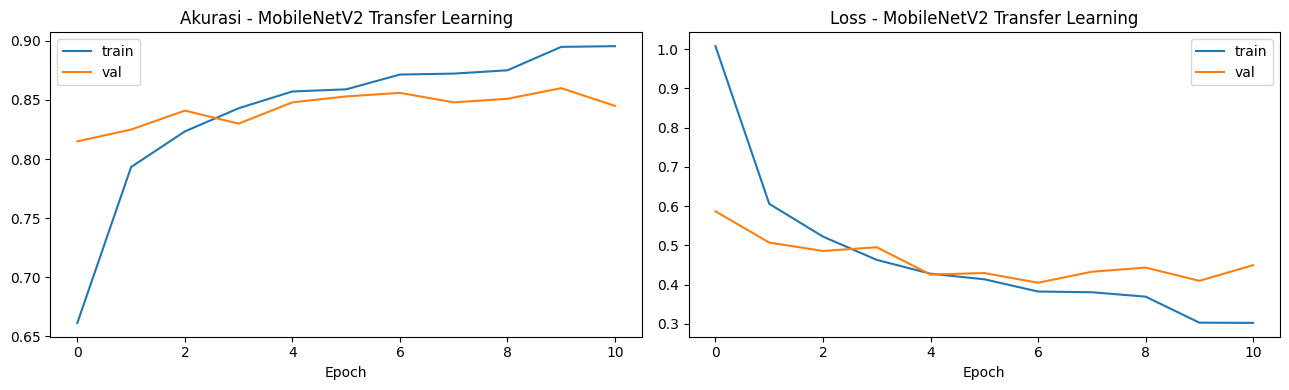

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(history_transfer.history["accuracy"], label="train")
axes[0].plot(history_transfer.history["val_accuracy"], label="val")
axes[0].set_title("Akurasi - MobileNetV2 Transfer Learning")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history_transfer.history["loss"], label="train")
axes[1].plot(history_transfer.history["val_loss"], label="val")
axes[1].set_title("Loss - MobileNetV2 Transfer Learning")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

### Analisis Hasil

Berdasarkan kurva training, MobileNetV2 dengan pendekatan *transfer learning* menunjukkan proses pembelajaran yang cukup baik. Akurasi training meningkat dari sekitar **66% pada epoch pertama** hingga mencapai sekitar **90% pada epoch terakhir**. Sementara itu, akurasi validation sejak awal sudah berada pada sekitar **82%** dan meningkat hingga mencapai nilai tertinggi sekitar **86%** sebelum mengalami sedikit penurunan pada epoch terakhir.

Perbedaan antara akurasi training dan validation masih relatif kecil pada sebagian besar epoch. Bahkan pada beberapa epoch awal, akurasi validation lebih tinggi daripada training. Kondisi ini dapat terjadi karena model menggunakan bobot pretrained ImageNet dan selama training terdapat mekanisme seperti *Dropout* yang membuat proses training lebih sulit dibandingkan evaluasi pada data validation. Pola tersebut menunjukkan bahwa model tidak langsung mengalami overfitting pada awal training.

Namun, mulai sekitar epoch ke-6, akurasi training terus meningkat hingga mendekati **90%**, sedangkan akurasi validation cenderung berada pada kisaran **85–86%** dan mulai berfluktuasi. Hal ini menunjukkan adanya **indikasi overfitting ringan**. Model semakin baik dalam menyesuaikan diri terhadap data training, tetapi peningkatan tersebut tidak sepenuhnya diikuti oleh peningkatan kemampuan generalisasi pada data validation.

Pola yang sama terlihat pada kurva *loss*. Training loss mengalami penurunan yang konsisten dari sekitar **1,0** menjadi sekitar **0,30**. Sebaliknya, validation loss turun hingga sekitar **0,40 pada epoch ke-6**, kemudian kembali meningkat dan berfluktuasi hingga mencapai sekitar **0,45 pada epoch terakhir**. Kondisi ini menjadi indikasi yang lebih jelas bahwa setelah titik tertentu, peningkatan pembelajaran pada data training tidak lagi menghasilkan perbaikan pada data validation.

Dengan demikian, **epoch terakhir bukan merupakan titik optimal dari sisi generalisasi**. Validation accuracy terbaik terlihat sekitar **epoch ke-9**, yaitu sekitar **86%**, sedangkan validation loss terendah berada sekitar **epoch ke-6**. Perbedaan titik terbaik tersebut menunjukkan bahwa pemilihan model sebaiknya tidak hanya didasarkan pada training accuracy, tetapi juga mempertimbangkan metrik validation dan tujuan evaluasi yang digunakan.

Secara keseluruhan, MobileNetV2 berhasil memanfaatkan fitur pretrained untuk mencapai performa yang cukup baik dengan proses pembelajaran yang relatif cepat. Namun, setelah beberapa epoch, model mulai menunjukkan tanda-tanda overfitting ringan yang ditandai oleh training loss yang terus menurun sementara validation loss cenderung meningkat. Oleh karena itu, penggunaan **EarlyStopping** dan **ModelCheckpoint** tetap penting untuk mempertahankan bobot pada epoch dengan performa validation terbaik, bukan secara otomatis menggunakan bobot pada epoch terakhir.


=== MobileNetV2 Transfer ===
Accuracy      : 0.8560
F1 Score (macro)   : 0.8539
F1 Score (weighted): 0.8539

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.84      0.93      0.88       100
                        Tomato___Early_blight       0.92      0.68      0.78       100
                         Tomato___Late_blight       0.89      0.98      0.93       100
                           Tomato___Leaf_Mold       0.83      0.91      0.87       100
                  Tomato___Septoria_leaf_spot       0.78      0.82      0.80       100
Tomato___Spider_mites Two-spotted_spider_mite       0.88      0.78      0.83       100
                         Tomato___Target_Spot       0.81      0.76      0.78       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.95      0.95      0.95       100
                 Tomato___Tomato_mosaic_virus       0.93      0.77      0.84       100
                    

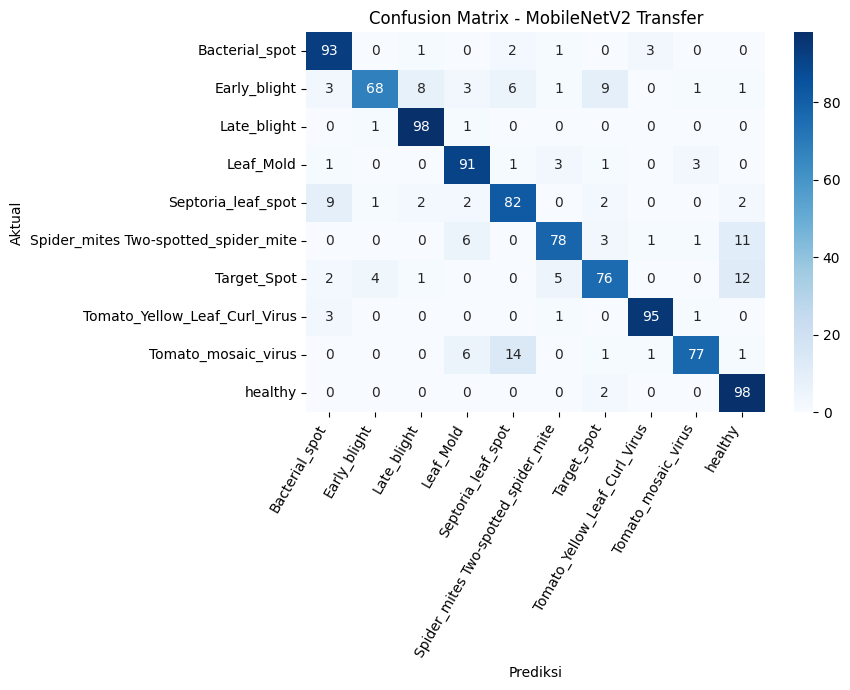

In [29]:
results_transfer = evaluate_model(transfer_model, transfer_val_gen, "MobileNetV2 Transfer")

In [30]:
if not TRANSFER_LEARNING_IS_REAL:
    print("\n" + "="*80)
    print("metrik MobileNetV2 di atas dihasilkan dari bobot ACAK, bukan bobot ImageNet asli")
    print("Jalankan ulang (QUICK_DEMO=False) untuk hasil transfer learning valid.")
    print("="*80)
else:
    print("Bobot ImageNet asli berhasil dipakai.")

Bobot ImageNet asli berhasil dipakai -- hasil di atas representatif untuk transfer learning.


### Analisis Hasil Evaluasi

Berdasarkan hasil evaluasi pada data uji, MobileNetV2 dengan pendekatan *transfer learning* memperoleh **Accuracy sebesar 85,60%** dan **F1 Score macro sebesar 85,39%**. Nilai F1 Score yang hampir sama dengan Accuracy menunjukkan bahwa performa model secara keseluruhan relatif seimbang antar kelas, meskipun masih terdapat beberapa kelas dengan performa yang lebih rendah.

**a. Analisis Per Kelas**

Performa terbaik diperoleh pada kelas **Tomato_Yellow_Leaf_Curl_Virus** dengan F1 Score **0,95** dan recall **0,95**, serta **Late_blight** dengan F1 Score **0,93** dan recall **0,98**. Hal ini menunjukkan bahwa MobileNetV2 cukup efektif dalam mengenali karakteristik visual kedua kelas tersebut.

Sebaliknya, performa terendah terlihat pada **Early_blight** dan **Target_Spot**, yang masing-masing memperoleh F1 Score **0,78**. Pada Early_blight, recall hanya **0,68**, yang berarti cukup banyak citra Early_blight yang salah diklasifikasikan sebagai kelas lain. Kondisi serupa terlihat pada Target_Spot dengan recall **0,76**. Kelas **Septoria_leaf_spot** juga masih memiliki performa relatif rendah dengan F1 Score **0,80**.

**b. Analisis Confusion Matrix**

Confusion matrix menunjukkan bahwa sebagian besar prediksi masih berada pada diagonal utama, tetapi terdapat beberapa pola kesalahan yang cukup jelas. **Early_blight** menjadi salah satu kelas yang paling sulit dikenali, dengan 68 citra yang berhasil diklasifikasikan dengan benar dan beberapa citra salah diprediksi sebagai **Late_blight, Target_Spot, Septoria_leaf_spot**, dan kelas lainnya.

Pada **Target_Spot**, sebanyak 76 citra berhasil diklasifikasikan dengan benar, sementara sebagian lainnya diprediksi sebagai **healthy, Spider_mites**, dan **Early_blight**. Selain itu, **Tomato_mosaic_virus** memiliki recall sebesar 0,77, dengan beberapa citra salah diklasifikasikan sebagai **Septoria_leaf_spot** dan **Leaf_Mold**.

Kesalahan tersebut menunjukkan bahwa MobileNetV2 masih mengalami kesulitan dalam membedakan beberapa kelas yang memiliki karakteristik visual yang mirip. Hal ini terutama terlihat pada kelas penyakit daun yang memiliki pola bercak atau perubahan warna yang serupa.

**c. Analisis Dibandingkan CNN Kustom**

Jika dibandingkan dengan CNN kustom yang memperoleh **Accuracy 94,10%** dan **F1 Score macro 94,09%**, MobileNetV2 memperoleh hasil yang lebih rendah, yaitu **85,60% Accuracy** dan **85,39% F1 Score macro**. Dengan demikian, pada konfigurasi eksperimen ini, penggunaan MobileNetV2 pretrained belum memberikan performa yang lebih baik dibandingkan CNN kustom.

Perbedaan tersebut menunjukkan bahwa penggunaan model pretrained tidak secara otomatis menghasilkan performa yang lebih tinggi. Pada eksperimen ini, seluruh *base model* MobileNetV2 dibekukan sehingga fitur yang digunakan masih berasal dari representasi ImageNet dan classifier baru harus menyesuaikannya dengan karakteristik spesifik citra daun tomat. Selain itu, kurva training sebelumnya menunjukkan adanya indikasi overfitting ringan, sehingga peningkatan akurasi training belum sepenuhnya diikuti oleh peningkatan performa validation.

Secara keseluruhan, MobileNetV2 tetap menunjukkan kemampuan klasifikasi yang cukup baik, terutama pada beberapa kelas seperti **Tomato_Yellow_Leaf_Curl_Virus** dan **Late_blight**. Namun, berdasarkan **Accuracy 85,60%** dan **F1 Score macro 85,39%**, CNN kustom memberikan hasil yang lebih baik pada konfigurasi eksperimen ini. Hasil tersebut menunjukkan bahwa arsitektur yang lebih sederhana tetapi dirancang dan dilatih secara khusus pada dataset dapat lebih sesuai dibandingkan fitur pretrained yang dibekukan sepenuhnya.


## 9. Perbandingan CNN Custom vs Transfer Learning

                      accuracy  f1_macro  f1_weighted
model                                                
CNN Custom               0.941  0.940883     0.940883
MobileNetV2 Transfer     0.856  0.853882     0.853882


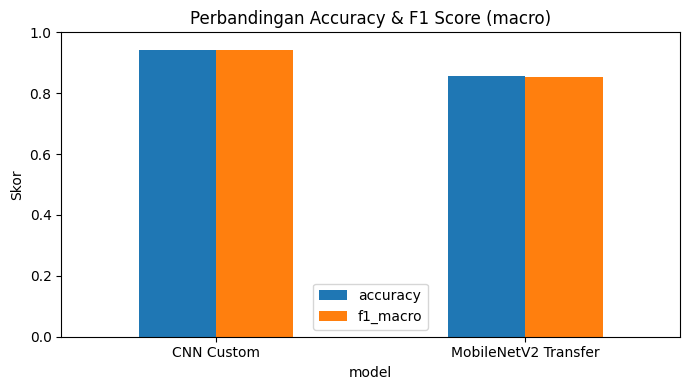

In [31]:
df_compare = pd.DataFrame([results_custom, results_transfer]).set_index("model")
print(df_compare)

df_compare[["accuracy","f1_macro"]].plot(kind="bar", figsize=(7,4))
plt.title("Perbandingan Accuracy & F1 Score (macro)")
plt.ylabel("Skor")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analisis Kelebihan dan Kekurangan Model

Pada penelitian ini digunakan dua pendekatan Convolutional Neural Network (CNN), yaitu **CNN Custom** yang dibangun dan dilatih dari awal serta **MobileNetV2 dengan pendekatan transfer learning**. Penggunaan kedua pendekatan tersebut bertujuan untuk membandingkan kemampuan model yang dirancang secara khusus dengan model yang memanfaatkan pengetahuan visual yang telah diperoleh sebelumnya melalui proses *pre-training*. Perbandingan ini dilakukan untuk mengetahui pendekatan yang lebih sesuai dengan karakteristik dataset serta mempertimbangkan aspek performa, kebutuhan data, waktu pelatihan, dan kompleksitas model.

Berdasarkan hasil evaluasi, **CNN Custom memberikan performa yang lebih baik dibandingkan MobileNetV2 Transfer**. CNN Custom memperoleh nilai **accuracy sebesar 0,941 atau 94,1%**, sedangkan nilai **F1-score macro sebesar 0,940883 atau sekitar 94,09%**. Sementara itu, MobileNetV2 Transfer memperoleh **accuracy sebesar 0,856 atau 85,6%** dan **F1-score macro sebesar 0,853882 atau sekitar 85,39%**.

| Model | Accuracy | F1-Score Macro |
|---|---:|---:|
| CNN Custom | 94,10% | 94,09% |
| MobileNetV2 Transfer | 85,60% | 85,39% |

Perbedaan tersebut menunjukkan bahwa pada konfigurasi eksperimen yang digunakan, CNN Custom mampu mengenali dan membedakan karakteristik visual pada dataset dengan lebih baik dibandingkan MobileNetV2 Transfer. Selisih accuracy antara kedua model mencapai sekitar **8,5 poin persentase**, sedangkan selisih F1-score macro mencapai sekitar **8,70 poin persentase**.

### CNN Custom

CNN Custom dipilih karena memungkinkan arsitektur jaringan disesuaikan secara langsung dengan karakteristik dataset penelitian. Berbeda dengan transfer learning yang menggunakan representasi fitur yang telah dipelajari dari dataset lain, CNN Custom mempelajari seluruh fitur secara langsung dari data yang digunakan dalam penelitian.

Pendekatan ini memungkinkan model untuk mempelajari karakteristik visual yang lebih spesifik terhadap objek pada dataset, seperti **warna, bentuk, tepi, tekstur, pola permukaan, serta karakteristik visual lain yang membedakan antar kelas**. Pada proses convolution, model secara bertahap mempelajari fitur sederhana seperti garis dan tepi, kemudian menggabungkannya menjadi fitur yang lebih kompleks. Dengan demikian, model dapat membentuk representasi yang lebih sesuai dengan karakteristik data penelitian.

Keunggulan tersebut terlihat dari hasil evaluasi. CNN Custom mampu mencapai accuracy sebesar **94,1%** dengan F1-score macro sebesar **94,09%**. Nilai F1-score macro yang hampir sama dengan accuracy menunjukkan bahwa performa model relatif konsisten ketika mempertimbangkan setiap kelas. Hal ini penting karena accuracy hanya menggambarkan proporsi prediksi yang benar secara keseluruhan, sedangkan F1-score macro memberikan gambaran performa model dengan menghitung F1-score setiap kelas kemudian mengambil nilai rata-ratanya.

Dengan kata lain, tingginya nilai F1-score macro menunjukkan bahwa kemampuan model dalam melakukan klasifikasi tidak hanya didominasi oleh kelas tertentu, tetapi relatif baik pada kelas-kelas yang dievaluasi.

Meskipun demikian, CNN Custom juga memiliki beberapa kekurangan. Karena model dilatih dari awal, seluruh parameter jaringan harus dipelajari berdasarkan dataset penelitian. Model perlu mempelajari fitur dasar seperti *edge*, tekstur, warna, dan bentuk sebelum dapat membangun fitur yang lebih kompleks. Oleh karena itu, CNN Custom pada umumnya membutuhkan data dan proses pelatihan yang cukup agar dapat menghasilkan representasi fitur yang optimal.

Selain itu, semakin kompleks arsitektur CNN yang digunakan, semakin besar pula kebutuhan terhadap sumber daya komputasi dan data. Apabila jumlah data relatif terbatas tetapi model memiliki kapasitas yang terlalu besar, terdapat risiko **overfitting**, yaitu kondisi ketika model terlalu menyesuaikan diri terhadap data training sehingga kemampuan generalisasinya terhadap data baru menjadi kurang optimal.

### MobileNetV2 dengan Transfer Learning

MobileNetV2 digunakan sebagai model pembanding karena pendekatan **transfer learning** memungkinkan model memanfaatkan pengetahuan visual yang telah diperoleh dari proses *pre-training*. Dengan pendekatan ini, model tidak harus mempelajari seluruh fitur visual dari awal.

MobileNetV2 sebelumnya telah dilatih menggunakan dataset berukuran besar sehingga telah memiliki kemampuan dalam mengenali berbagai fitur visual dasar, seperti **tepi, bentuk, tekstur, pola, dan kombinasi fitur visual lainnya**. Pengetahuan tersebut kemudian dimanfaatkan untuk menyelesaikan tugas klasifikasi pada dataset penelitian.

Pemilihan MobileNetV2 juga didasarkan pada karakteristik arsitekturnya yang relatif ringan dan efisien. Hal tersebut menjadi salah satu alasan MobileNetV2 banyak digunakan ketika penelitian atau aplikasi membutuhkan model dengan efisiensi komputasi yang baik. Dengan memanfaatkan model *pre-trained*, proses pelatihan dapat menjadi lebih efisien karena model sudah memiliki representasi fitur awal.

Secara teori, transfer learning juga dapat memberikan keuntungan terutama ketika dataset yang tersedia tidak terlalu besar. Model tidak perlu mempelajari seluruh fitur dari nol sehingga proses konvergensi dapat berlangsung lebih cepat dibandingkan model yang benar-benar dilatih dari awal.

Namun, hasil eksperimen menunjukkan bahwa MobileNetV2 Transfer memperoleh accuracy sebesar **85,6%**, lebih rendah dibandingkan CNN Custom yang mencapai **94,1%**. F1-score macro MobileNetV2 juga hanya mencapai **85,39%**, sedangkan CNN Custom mencapai **94,09%**.

Salah satu alasan yang memungkinkan terjadinya kondisi tersebut adalah adanya perbedaan karakteristik antara dataset yang digunakan untuk *pre-training* dengan dataset penelitian. MobileNetV2 memperoleh pengetahuan awal dari gambar-gambar umum, sedangkan dataset penelitian memiliki karakteristik objek yang lebih spesifik. Oleh karena itu, fitur yang telah dipelajari sebelumnya belum tentu sepenuhnya sesuai untuk membedakan karakteristik antar kelas pada dataset penelitian.

Apabila *base model* MobileNetV2 dalam eksperimen berada dalam kondisi **frozen**, sebagian besar fitur yang telah dipelajari sebelumnya tidak mengalami perubahan selama proses training. Akibatnya, model memiliki kemampuan yang lebih terbatas dalam menyesuaikan fitur tingkat tinggi dengan karakteristik dataset penelitian.

Salah satu pendekatan yang dapat dilakukan untuk meningkatkan performa MobileNetV2 adalah **fine-tuning**. Pada tahap ini, sebagian layer terakhir dari *base model* dapat dibuka kembali (*unfreeze*) sehingga bobotnya dapat disesuaikan dengan dataset penelitian. Dengan demikian, model tetap dapat memanfaatkan pengetahuan awal dari proses *pre-training*, tetapi juga memperoleh kesempatan untuk mempelajari fitur yang lebih spesifik terhadap dataset.

Namun, fine-tuning juga memiliki konsekuensi. Semakin banyak layer yang dibuka, semakin banyak parameter yang harus dilatih. Kondisi tersebut dapat meningkatkan kebutuhan waktu dan sumber daya komputasi serta meningkatkan risiko overfitting apabila jumlah data tidak mencukupi.

### Perbandingan Kedua Model

Berdasarkan hasil eksperimen, CNN Custom memberikan hasil yang lebih baik dibandingkan MobileNetV2 Transfer pada konfigurasi yang digunakan. CNN Custom memperoleh accuracy **94,1%**, sedangkan MobileNetV2 Transfer memperoleh accuracy **85,6%**.

Perbedaan tersebut dapat dirangkum sebagai berikut:

| Aspek | CNN Custom | MobileNetV2 Transfer |
|---|---|---|
| Pendekatan | Dilatih dari awal | Transfer learning |
| Fitur awal | Dipelajari dari dataset penelitian | Memanfaatkan fitur hasil pre-training |
| Fleksibilitas arsitektur | Tinggi | Mengikuti arsitektur MobileNetV2 |
| Adaptasi terhadap dataset | Sangat spesifik | Bergantung pada kemampuan adaptasi model |
| Accuracy | **94,10%** | 85,60% |
| F1-Score Macro | **94,09%** | 85,39% |
| Kebutuhan data | Relatif lebih tinggi | Relatif lebih rendah |
| Risiko overfitting | Dapat meningkat jika data terbatas | Tetap ada, terutama saat fine-tuning |
| Efisiensi komputasi | Bergantung pada arsitektur | Relatif efisien |

Berdasarkan perbandingan tersebut, CNN Custom memiliki keunggulan utama dalam hal kemampuan menyesuaikan arsitektur dan pembelajaran fitur terhadap karakteristik dataset. Hal ini kemungkinan menjadi salah satu faktor yang menyebabkan performanya lebih tinggi pada eksperimen yang dilakukan.

Di sisi lain, MobileNetV2 memiliki keunggulan dari sisi efisiensi dan pemanfaatan pengetahuan yang telah diperoleh dari dataset berukuran besar. Oleh karena itu, performa yang lebih rendah pada eksperimen ini tidak berarti bahwa MobileNetV2 secara umum lebih buruk dibandingkan CNN Custom. Performa transfer learning sangat bergantung pada kesesuaian domain data *pre-training*, strategi *freezing* dan *unfreezing* layer, jumlah data, serta konfigurasi *hyperparameter* yang digunakan.

### Kesimpulan Analisis

Berdasarkan hasil evaluasi, **CNN Custom merupakan model dengan performa terbaik pada eksperimen ini**, dengan accuracy sebesar **94,1%** dan F1-score macro sebesar **94,09%**. Hasil tersebut menunjukkan bahwa model yang dilatih dari awal mampu mempelajari karakteristik spesifik dataset dengan baik.

Sementara itu, MobileNetV2 Transfer memperoleh accuracy sebesar **85,6%** dan F1-score macro sebesar **85,39%**. Meskipun performanya lebih rendah, MobileNetV2 tetap memiliki keunggulan dalam hal pemanfaatan fitur hasil *pre-training* dan efisiensi model, sehingga pendekatan ini tetap relevan terutama ketika jumlah data, waktu training, atau sumber daya komputasi menjadi pertimbangan utama.

Dengan demikian, berdasarkan konfigurasi eksperimen yang digunakan, **CNN Custom lebih sesuai untuk dataset penelitian ini**. Namun, kesimpulan tersebut tidak dapat digunakan untuk menyatakan bahwa CNN Custom selalu lebih unggul daripada transfer learning. Performa kedua pendekatan masih dapat berubah apabila dilakukan eksperimen dengan dataset yang lebih besar, jumlah *epoch* yang lebih optimal, penyesuaian *hyperparameter*, serta proses *fine-tuning* pada MobileNetV2.

## 10. Simpan Model Terbaik

Pada tahap ini dilakukan proses **pemilihan dan penyimpanan model terbaik** berdasarkan nilai **F1-score macro** pada *validation set*. Pemilihan model tidak hanya didasarkan pada nilai accuracy karena penelitian ini menggunakan **10 kelas**. Oleh karena itu, F1-score macro digunakan sebagai metrik utama karena mempertimbangkan performa model pada setiap kelas secara lebih seimbang.


In [32]:
best_model_info = max([results_custom, results_transfer], key=lambda r: r["f1_macro"])
print("Model terbaik:", best_model_info["model"])
print(best_model_info)

save_path_h5 = "/kaggle/working/tomato_leaf_best_model.h5"
os.makedirs("/kaggle/working", exist_ok=True)   

if best_model_info["model"] == "CNN Custom":
    custom_model.save(save_path_h5)
else:
    transfer_model.save(save_path_h5)

print(f"Model tersimpan di: {save_path_h5}")

Model terbaik: CNN Custom
{'model': 'CNN Custom', 'accuracy': 0.941, 'f1_macro': 0.9408828389029118, 'f1_weighted': 0.9408828389029118}
Model tersimpan di: /kaggle/working/tomato_leaf_best_model.h5


In [ ]:
# ============================================================
# Simpan KEDUA model (.h5) untuk keperluan deployment Streamlit
# Tugas deployment meminta minimal 2 model yang dibandingkan
# di aplikasi, jadi custom_model dan transfer_model disimpan
# terpisah (bukan cuma yang terbaik).
# ============================================================
import os

os.makedirs("/kaggle/working/models", exist_ok=True)

custom_model.save("/kaggle/working/models/custom_cnn.h5")
transfer_model.save("/kaggle/working/models/mobilenet_transfer.h5")

print("Tersimpan:")
print(" - /kaggle/working/models/custom_cnn.h5")
print(" - /kaggle/working/models/mobilenet_transfer.h5")
print("\nDownload kedua file ini dari tab Output Kaggle,")
print("lalu taruh di folder models/ pada project Streamlit.")